In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd

# In class practice 7

## 1. Please perform T test to check whether the annual maximum streamflow has a significant change before and after Year 1980.

The Annual Maximum Streamflow is stored at `annual_maximum_flow.USGS_04216000.Niagara_River.csv`

If you don't know how to code, can you **vibe** coding??

In [4]:
# Insert your code here
df = pd.read_csv("annual_maximum_flow.USGS_04216000.Niagara_River.csv",index_col=0)

# take a look at the data
df


,04216000
year,
1940,235000.0
1941,219000.0
1942,255000.0
1943,245000.0
1944,236000.0
...,...
2018,295000.0
2019,309000.0
2020,313000.0


In [16]:
df_prior_1980 = df.loc[1940:1980] # select all data prior to and including 1980
df_post_1980 = df.loc[slice(1981,2023)] # a different way to select all data after 1980

In [19]:
# df_post_1980

In [21]:
# now let's convert the dataframe format to a numpy array format
df_prior_1980_array = df_prior_1980['04216000'].values
df_post_1980_array = df_post_1980['04216000'].values

In [22]:
# Now, let's do the two sample t test
from scipy.stats import ttest_ind
t_statistic, p_value = ttest_ind(df_prior_1980_array, df_post_1980_array)
print("t statistic:", t_statistic)
print("p value:", p_value)

t statistic: -3.106682783751227
p value: 0.002608570553652945


p value is smaller than 0.05, therefore, there is significant changes in the annual peak flow before and after 1980

## 2. Practice loops and if statement

### 2.1. Can you find the 25th and 75th percentile of the annual maximum streamflow?

In [23]:
# Insert your code here
annual_max_flow = df['04216000'].values

amax_flow_25 = np.percentile(annual_max_flow,25)
amax_flow_75 = np.percentile(annual_max_flow,75)

print(f"The 25th percentile of the annual max flow is {amax_flow_25} cfs")
print(f"The 75th percentile of the annual max flow is {amax_flow_75} cfs")

The 25th percentile of the annual max flow is 242000.0 cfs
The 75th percentile of the annual max flow is 278000.0 cfs


### 2.2. Can you list the years falls below 25th percentile and print the years with their corresponding annual max flow?

In [25]:
# Insert your code here
for row in df.iterrows():
    year = row[0]
    flow = row[1]['04216000']
    if flow < amax_flow_25:
        print(f"In {year}, the annual max flow was {flow} cfs, which is below the 25th percentile.")

In 1940, the annual max flow was 235000.0 cfs, which is below the 25th percentile.
In 1941, the annual max flow was 219000.0 cfs, which is below the 25th percentile.
In 1944, the annual max flow was 236000.0 cfs, which is below the 25th percentile.
In 1949, the annual max flow was 236000.0 cfs, which is below the 25th percentile.
In 1958, the annual max flow was 225000.0 cfs, which is below the 25th percentile.
In 1959, the annual max flow was 216000.0 cfs, which is below the 25th percentile.
In 1960, the annual max flow was 237000.0 cfs, which is below the 25th percentile.
In 1961, the annual max flow was 234000.0 cfs, which is below the 25th percentile.
In 1962, the annual max flow was 227000.0 cfs, which is below the 25th percentile.
In 1963, the annual max flow was 234000.0 cfs, which is below the 25th percentile.
In 1964, the annual max flow was 198000.0 cfs, which is below the 25th percentile.
In 1965, the annual max flow was 220000.0 cfs, which is below the 25th percentile.
In 1

### 2.3. Interesting visualization

1. Basic: please do a scatter plot where x-axis denotes year, and y-axis denotes annual maximum flow.
2. Advanced: for the year with maximum streamflow above the 75th percentile, please use blue dots; for the year with maximum streamflow below the 25th percentile, please use red dots; for the year with maximum streamflow falling between the 25th and 75th percentiles, please use gray dots.


Text(0, 0.5, 'Annual Maximum Flow (cfs)')

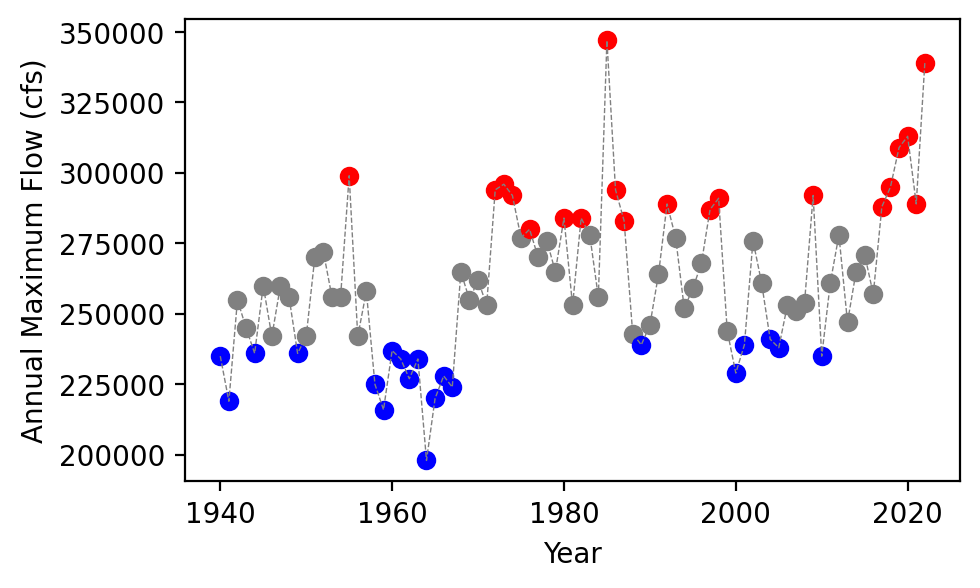

In [34]:
# Insert your code here
import matplotlib.pyplot as plt
plt.figure(figsize=[5,3],dpi=200)

plt.plot(df.index.values, df['04216000'].values, color='gray', lw=0.5,ls='--')

for row in df.iterrows():
    year = row[0]
    flow = row[1]['04216000']
    if flow < amax_flow_25:
        plt.scatter(year, flow, color='blue', label='below 25th percentile')
    elif flow > amax_flow_75:
        plt.scatter(year, flow, color='red', label='above 75th percentile')
    else:
        plt.scatter(year, flow, color='gray', label='between 25th and 75th percentile')

plt.xlabel("Year")
plt.ylabel("Annual Maximum Flow (cfs)")